In [ ]:
# time
# Start time
start_localtime=time.localtime()
start_time_zt=time.time()
print("Start time: ",time.strftime("%Y-%m-%d-%H:%M:%S", start_localtime))

# Start train
# train_model(args)

# End time, time_cost
print("Start time: ",time.strftime("%Y-%m-%d-%H:%M:%S", start_localtime))
print("End time: ",time.strftime("%Y-%m-%d-%H:%M:%S", time.localtime()))
end_time_zt=time.time()
cost_zt=end_time_zt-start_time_zt
m, s = divmod(cost_zt, 60)
h, m = divmod(m, 60)
print ("Time cost: ", "%02d:%02d:%02d" % (h, m, s))

In [6]:
import torch
import torch.nn as nn

# 假设你有模型的预测输出和真实标签
# 假设预测输出的形状为 (batch_size, num_classes, height, width)，真实标签的形状为 (batch_size, height, width)
# 注意：预测输出的第一个维度是类别概率分布，你可以使用 softmax 函数或者在模型中包含 softmax 层来获得这样的输出

# 创建模型实例
num_classes = 21  # 替换为你任务中的类别数量
# model = YourModel(num_classes)

# 假设你有模型的预测输出和真实标签
# 这里简化为示例数据
batch_size = 32
height = 256
width = 256
num_classes = 21
predictions = torch.rand(batch_size, num_classes, height, width)  # 模型的预测输出
labels = torch.randint(0, num_classes, (batch_size, height, width))  # 真实标签

# 定义交叉熵损失函数
criterion = nn.CrossEntropyLoss()

# 计算损失
loss = criterion(predictions, labels)

# 打印损失值
print('Loss:', loss.item())


Loss: 3.084024667739868


In [5]:
# plot
import matplotlib.pyplot as plt
import numpy as np
def plot_train_test_trend(train_losses, test_losses, save_path=None, ylabel='Loss', train_label='train', test_label='val'):
    """
    绘制训练和测试损失的趋势图，并可选地保存为图片
    
    参数：
    - train_losses: 训练损失列表
    - test_losses: 测试损失列表
    - save_path: 图片保存路径，如果为 None则不保存图片, 默认为 None
    """
    # 创建 x 轴数据，表示每个 epoch
    epochs = np.arange(1, len(train_losses) + 1)

    # 绘制训练和测试损失的趋势图
    plt.figure()
    plt.plot(epochs, train_losses, label=train_label)
    plt.plot(epochs, test_losses, label=test_label)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(ylabel + ': train vs val')
    plt.legend()
    plt.grid(True)
    
    # 如果提供了保存路径，则保存图片
    if save_path is not None:
        plt.savefig(save_path)
        print(f"图片已保存为 {save_path}")
    else:
        plt.show()

In [ ]:
# plot_train_test_trend([0.5,0.6,0.4,0.5,0.6,0.4], [0.4,0.3,0.1,0.6,0.2,0.3],'./fig1',"ylabelll")
plot_train_test_trend([[0.5,0.6],[0.4,0.5],[0.6,0.4]], [[0.4,0.3],[0.1,0.6],[0.2,0.3]],'./fig1',"ious",['train1', 'train2'], ['val1', 'val2'])

In [2]:
range(10)
list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [15]:
import numpy as np
ious = [1,2,3,4]
ious_list=[]
for i in range(4):
    ious_list.append(ious)
print(ious_list)
print(np.mean(ious_list,axis=1))
print(np.mean(ious_list,axis=0))

[[1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4]]
[2.5 2.5 2.5 2.5]
[1. 2. 3. 4.]


In [4]:
import numpy as np
list = np.arange(16).reshape(4,4)
print(list)
for i in range(4):
    print(list[:,i])

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[ 0  4  8 12]
[ 1  5  9 13]
[ 2  6 10 14]
[ 3  7 11 15]


In [14]:
import numpy as np
index_name_list = ['OA', 'kappa', 'precision', 'recall', 'F1', 'miou']
train_index_list = [list(range(6)) for i in range(4)]
print(train_index_list)
# train_index_list = np.array(train_index_list)
print(np.array(train_index_list))
# print(train_index_list[0:2, 0:2])
for i, index in enumerate(index_name_list):
    print(i, index)
    print(f'train {index}, ', np.array(train_index_list)[:,i])

[[0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5]]
[[0 1 2 3 4 5]
 [0 1 2 3 4 5]
 [0 1 2 3 4 5]
 [0 1 2 3 4 5]]
0 OA
train OA,  [0 0 0 0]
1 kappa
train kappa,  [1 1 1 1]
2 precision
train precision,  [2 2 2 2]
3 recall
train recall,  [3 3 3 3]
4 F1
train F1,  [4 4 4 4]
5 miou
train miou,  [5 5 5 5]


In [10]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

num = 30
true = [i%3 for i in range(num)]
pred = [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 2, 1, 2, 1, 0, 0, 1, 2, 2]
print(true, pred)
print("OA:",accuracy_score(true, pred))
print("precision:", precision_score(true, pred, average='micro'))
print("recall:", recall_score(true, pred, average='micro'))
print("f1_score:", f1_score(true, pred, average='micro'))


[0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2] [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 2, 1, 2, 1, 0, 0, 1, 2, 2]
OA: 0.8
precision: 0.8
recall: 0.8
f1_score: 0.8000000000000002


In [4]:
# test torch.nn.functional.one_hot
import torch
import torch.nn.functional as F
x = torch.tensor([[0, 1, 2, 3], [0, 1, 2, 3]])
print(x.shape)
onehot = F.one_hot(x, num_classes=5)
print(onehot)
print(onehot.shape)


torch.Size([2, 4])
tensor([[[1, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 0, 0, 1, 0]],

        [[1, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 0, 0, 1, 0]]])
torch.Size([2, 4, 5])


In [7]:


from typing import List

def argu_test(loss_list: List):
    loss_list.append(1)
    return loss_list

my_list = [1,2,3]
# once_list = []
once_list = argu_test(my_list)
print(my_list)
print(once_list)
print(my_list is once_list)

[1, 2, 3, 1]
[1, 2, 3, 1]
True


In [2]:
list1 = [1, 2, 3]
list2 = [4, 5, 6]

# 创建一个空的二维列表
list_2d = [list1, list2]

print(list_2d)  # 输出：[[1, 2, 3], [4, 5, 6]]

[[1, 2, 3], [4, 5, 6]]


In [ ]:
from train import plot_train_test_trend
import numpy as np
train_preloss = [0.5,0.6,0.7]
train_dice = [0.4,0.5,0.1]
train_preloss_dice_list=[list(i) for i in zip(train_preloss, train_dice)]
val_preloss = [0.4,0.3,0.2]
val_dice = [0.1,0.6,0.3]
val_preloss_dice_list=[i for i in zip(val_preloss, val_dice)]
result_path='./'
plot_train_test_trend(train_preloss_dice_list, val_preloss_dice_list, ylabel='loss_dice', 
                              save_path=result_path, fig_name='fig_preloss_dice',
                              train_label=['train_preloss', 'train_dice'], test_label=['val_preloss', 'val_dice'])
print(['train'+str(i) for i in range(2)])
print(['train_preloss', 'train_dice'])
print(train_preloss_dice_list, val_preloss_dice_list)

In [ ]:
import torch
import torchmetrics

# 假设你有10个类别
num_classes = 10

# 初始化IoU计算器
iou = torchmetrics.IoU(num_classes=num_classes)

# 假设你有一些预测结果和真实标签
# 这些张量的形状应该是(N, H, W)，其中N是批次大小，H和W是高度和宽度
preds = torch.randint(num_classes, (10, 32, 32))
targets = torch.randint(num_classes, (10, 32, 32))

# 更新IoU计算器
iou(preds, targets)

# 计算IoU
iou.compute()

# 获取每个类别的IoU
class_iou = iou.iou

print(class_iou)

In [7]:
import time
from torch.utils import data
from component.dataset import get_dataset_reader

dataset_name = 'rgbn'
data_path = r"E:\Yiling\at_SIAT_research\1_dataset\dataset\dwq_sentinel2\train_val"
batch_size = 16

dataset_reader = get_dataset_reader(dataset_name)
train_dateset = dataset_reader(root_dir=data_path, is_train=True, transform= None)


for i in range(1, 10):
    train_loader = data.DataLoader(train_dateset, batch_size=batch_size, shuffle=True, num_workers=i)
    # 计时开始
    start_time = time.time()
    for batch in train_loader:
        pass
    # 计时结束并打印耗时
    print(f"num_workers: {i}, time cost: {time.time() - start_time:.4f}sec")

# total train images: 5963
# num_workers: 1, time cost: 11.0806sec
# num_workers: 2, time cost: 7.0003sec
# num_workers: 3, time cost: 6.6967sec
# num_workers: 4, time cost: 6.9685sec
# num_workers: 5, time cost: 7.6606sec
# num_workers: 6, time cost: 8.5535sec
# num_workers: 7, time cost: 9.2808sec
# num_workers: 8, time cost: 10.0008sec
# num_workers: 9, time cost: 11.0774sec


total train images: 5963
num_workers: 1, time cost: 11.0806sec
num_workers: 2, time cost: 7.0003sec
num_workers: 3, time cost: 6.6967sec
num_workers: 4, time cost: 6.9685sec
num_workers: 5, time cost: 7.6606sec
num_workers: 6, time cost: 8.5535sec
num_workers: 7, time cost: 9.2808sec
num_workers: 8, time cost: 10.0008sec
num_workers: 9, time cost: 11.0774sec


In [1]:
# 打印unet网络的每一层的名称和形状
from component.model import get_model
import torch
model_arch = 'unet'
n_classes = 9
band_num = 4

model_init = get_model(model_arch)
model = model_init(n_classes = n_classes, in_channels = band_num)

X = torch.randn(size=(1,4,256,256))
for layer in model:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

CHANNEL: 4


TypeError: 'UNet' object is not iterable

In [1]:
# 2024/04/22, origin unet
from torchsummary import summary
from component.model import get_model

model_arch = 'unet++'
n_classes = 9
band_num = 4

model_init = get_model(model_arch)
model = model_init(n_classes = n_classes, in_channels = band_num)
model.to(device = 'cuda')

# 假设你已经定义了一个模型
# model = ...

# 假设你的输入数据的形状是(4, 256, 256)
input_size = (4, 256, 256)

# 打印模型的每一层的详细信息
summary(model, input_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           2,368
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              ReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,928
       BatchNorm2d-5         [-1, 64, 256, 256]             128
              ReLU-6         [-1, 64, 256, 256]               0
 conv_block_nested-7         [-1, 64, 256, 256]               0
         MaxPool2d-8         [-1, 64, 128, 128]               0
            Conv2d-9        [-1, 128, 128, 128]          73,856
      BatchNorm2d-10        [-1, 128, 128, 128]             256
             ReLU-11        [-1, 128, 128, 128]               0
           Conv2d-12        [-1, 128, 128, 128]         147,584
      BatchNorm2d-13        [-1, 128, 128, 128]             256
             ReLU-14        [-1, 128, 1

In [1]:
# 2024/04/22, unet zt
        # # self.outc = nn.Conv2d(64, n_classes, kernel_size=1, padding=0)
        # self.outc = nn.Sequential(
        #     nn.Conv2d(64, 64, kernel_size=1, padding=0),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(64, n_classes, kernel_size=1, padding=0),
        #     nn.ReLU(inplace=True),
        #     nn.Conv2d(n_classes, n_classes, kernel_size=1, padding=0)
        # )
from torchinfo import summary
from component.model import get_model

model_arch = 'unet'
n_classes = 9
band_num = 4

model_init = get_model(model_arch)
model = model_init(n_classes = n_classes, in_channels = band_num)
model.to(device = 'cuda')

# 假设你已经定义了一个模型
# model = ...

# 假设你的输入数据的形状是(4, 256, 256)
input_size = (1, 4, 256, 256)

# 打印模型的每一层的详细信息
print(summary(model, input_size, col_names=["input_size", "output_size", "num_params"], verbose=1, mode='train'))

CHANNEL: 4
Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
UNet                                          [1, 4, 256, 256]          [1, 9, 256, 256]          --
├─double_conv: 1-1                            [1, 4, 256, 256]          [1, 64, 256, 256]         --
│    └─Sequential: 2-1                        [1, 4, 256, 256]          [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                       [1, 4, 256, 256]          [1, 64, 256, 256]         2,368
│    │    └─BatchNorm2d: 3-2                  [1, 64, 256, 256]         [1, 64, 256, 256]         128
│    │    └─ReLU: 3-3                         [1, 64, 256, 256]         [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                       [1, 64, 256, 256]         [1, 64, 256, 256]         36,928
│    │    └─BatchNorm2d: 3-5                  [1, 64, 256, 256]         [1, 64, 256, 256]         128
│    │    └─ReLU: 3-6                         [1, 64, 256, 256]   

In [1]:
from torchinfo import summary
from component.model import get_model

model_arch = 'unet'
n_classes = 9
band_num = 4

model_init = get_model(model_arch)
model = model_init(n_classes = n_classes, in_channels = band_num)
model.to(device = 'cuda')

# 假设你已经定义了一个模型
# model = ...

# 假设你的输入数据的形状是(4, 256, 256)
input_size = (1, 4, 256, 256)

# 打印模型的每一层的详细信息
print(summary(model, input_size, col_names=["input_size", "output_size", "num_params"], verbose=1, mode='train'))

CHANNEL: 4
Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
UNet                                          [1, 4, 256, 256]          [1, 9, 256, 256]          --
├─double_conv: 1-1                            [1, 4, 256, 256]          [1, 64, 256, 256]         --
│    └─Sequential: 2-1                        [1, 4, 256, 256]          [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                       [1, 4, 256, 256]          [1, 64, 256, 256]         2,368
│    │    └─BatchNorm2d: 3-2                  [1, 64, 256, 256]         [1, 64, 256, 256]         128
│    │    └─ReLU: 3-3                         [1, 64, 256, 256]         [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                       [1, 64, 256, 256]         [1, 64, 256, 256]         36,928
│    │    └─BatchNorm2d: 3-5                  [1, 64, 256, 256]         [1, 64, 256, 256]         128
│    │    └─ReLU: 3-6                         [1, 64, 256, 256]   

In [1]:
from torchinfo import summary
from component.model import get_model

model_arch = 'unet++'
n_classes = 9
band_num = 4

model_init = get_model(model_arch)
model = model_init(n_classes = n_classes, in_channels = band_num)
model.to(device = 'cuda')

# 假设你已经定义了一个模型
# model = ...

# 假设你的输入数据的形状是(4, 256, 256)
input_size = (1, 4, 256, 256)

# 打印模型的每一层的详细信息
print(summary(model, input_size, col_names=["input_size", "output_size", "num_params"], verbose=1, mode='train'))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
NestedUNet                               [1, 4, 256, 256]          [1, 9, 256, 256]          --
├─conv_block_nested: 1-1                 [1, 4, 256, 256]          [1, 64, 256, 256]         --
│    └─Conv2d: 2-1                       [1, 4, 256, 256]          [1, 64, 256, 256]         2,368
│    └─BatchNorm2d: 2-2                  [1, 64, 256, 256]         [1, 64, 256, 256]         128
│    └─ReLU: 2-3                         [1, 64, 256, 256]         [1, 64, 256, 256]         --
│    └─Conv2d: 2-4                       [1, 64, 256, 256]         [1, 64, 256, 256]         36,928
│    └─BatchNorm2d: 2-5                  [1, 64, 256, 256]         [1, 64, 256, 256]         128
│    └─ReLU: 2-6                         [1, 64, 256, 256]         [1, 64, 256, 256]         --
├─MaxPool2d: 1-2                         [1, 64, 256, 256]         [1, 64, 128, 128]         --
├─conv_block_nested: 1-3  

In [6]:
list = [i for i in range(10)]
print(list)
print(*list)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
0 1 2 3 4 5 6 7 8 9


c:\Users\ZT\.conda\envs\dltest\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


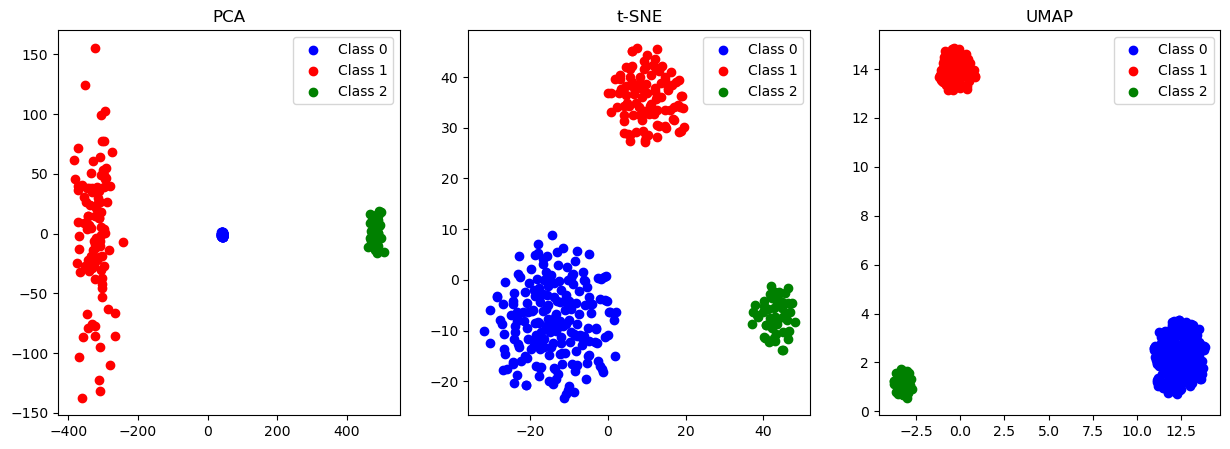

In [65]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(2)

# 假设你有一个高维特征矩阵X
# 生成一个4维张量
# X = np.random.randn(20, 20, 20).reshape(20, -1)
# 生成一个来自正态分布的高维矩阵，形状为(10, 20, 30)
X1 = np.random.normal(loc=5, scale=1, size=(200, 64))
X2 = np.random.normal(loc=50, scale=30, size=(100, 64))
X3 = np.random.normal(loc=-50, scale=10, size=(50, 64))
# 将矩阵沿着第一个轴（即行）合并为一个矩阵
X = np.concatenate((X1, X2, X3), axis=0).reshape(X1.shape[0] + X2.shape[0] + X3.shape[0], -1)

y = np.concatenate((np.zeros(X1.shape[0]), np.ones(X2.shape[0]), np.full(X3.shape[0],2)))

# 使用PCA降维
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)

# 使用t-SNE降维
tsne = TSNE(n_components=2, perplexity=10, random_state=0)
X_tsne = tsne.fit_transform(X)

# 使用UMAP降维
umap_reducer = umap.UMAP(random_state=42)
X_umap = umap_reducer.fit_transform(X)

# 可视化
plt.figure(figsize=(5*3, 5))
# PCA
plt.subplot(131)
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], c='blue', label='Class 0')
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], c='red', label='Class 1')
plt.scatter(X_pca[y==2, 0], X_pca[y==2, 1], c='green', label='Class 2')
plt.title('PCA')
plt.legend()
# t-SNE
plt.subplot(132)
plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1], c='blue', label='Class 0')
plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1], c='red', label='Class 1')
plt.scatter(X_tsne[y==2, 0], X_tsne[y==2, 1], c='green', label='Class 2')
plt.title('t-SNE')
plt.legend()
# UMAP
plt.subplot(133)
plt.scatter(X_umap[y==0, 0], X_umap[y==0, 1], c='blue', label='Class 0')
plt.scatter(X_umap[y==1, 0], X_umap[y==1, 1], c='red', label='Class 1')
plt.scatter(X_umap[y==2, 0], X_umap[y==2, 1], c='green', label='Class 2')
plt.title('UMAP')
plt.legend()

plt.show()

In [16]:
# from collections import defaultdict
# class_counts = {0:100, 1:200, 2:100, 3:200}
# print(class_counts[0])
# class_percentages = {k: v / sum(class_counts.values()) for k, v in class_counts.items()}
# print(class_percentages)
# print(list(class_percentages.values()))
# print(class_percentages.items())
# print(list(class_percentages.items()))

# # print([percentage for percentage in [class_counts[i]/sum(class_counts.values()) for i in range(3)]])
# # print(f'{0.165468:0.2f}')

from collections import defaultdict
class_counts = defaultdict(int)
class_counts[0] += 100
class_counts[1] += 200
class_counts[2] += 100
class_counts[3] += 200
print(class_counts)
print(dict(class_counts))
print(list(class_counts.values()))
print(class_counts[0])
class_percentages = {k: v / sum(class_counts.values()) for k, v in class_counts.items()}
print(class_percentages)
print(list(class_percentages.values()))
print(class_percentages.items())
print(list(class_percentages.items()))

defaultdict(<class 'int'>, {0: 100, 1: 200, 2: 100, 3: 200})
{0: 100, 1: 200, 2: 100, 3: 200}
[100, 200, 100, 200]
100
{0: 0.16666666666666666, 1: 0.3333333333333333, 2: 0.16666666666666666, 3: 0.3333333333333333}
[0.16666666666666666, 0.3333333333333333, 0.16666666666666666, 0.3333333333333333]
dict_items([(0, 0.16666666666666666), (1, 0.3333333333333333), (2, 0.16666666666666666), (3, 0.3333333333333333)])
[(0, 0.16666666666666666), (1, 0.3333333333333333), (2, 0.16666666666666666), (3, 0.3333333333333333)]


In [1]:
import torch
# # 假设你有一个Tensor列表
# tensor_list = [torch.tensor(1), torch.tensor(2), torch.tensor(3)]
# print(tensor_list)
# # print(tensor_list.tolist())
# # 使用列表推导式和.item()方法将Tensor列表转换为Python列表
# python_list = [t.item() for t in tensor_list]
# print(python_list)  # 输出: [1, 2, 3]

list1 = [1, 2, 3]
to_tensor = torch.tensor(list1)
print(to_tensor)
print(list(to_tensor))
print(to_tensor.tolist())


tensor([1, 2, 3])
[tensor(1), tensor(2), tensor(3)]
[1, 2, 3]


In [10]:
import numpy as np

# 随机生成一个[1, 4, 256, 256]的np数组，取值只有0或1
array = np.random.choice([0, 1], size=(1, 4, 256, 256))
print(array.size)
print(np.sum(array))
print(np.sum(array) / array.size)

262144
131467
0.5015068054199219


In [3]:
import numpy as np

val_index_list=[]
batch_val_index=[]

for i in range(5):
    batch_val_index.append([1,2,3,4,5,1,2])

val_index_list.append(np.mean(batch_val_index,axis=0))
print(val_index_list)

[array([1., 2., 3., 4., 5., 1., 2.])]
